In [84]:
from datasets import load_dataset

ds = load_dataset("westenfelder/NL2SH-ALFA", "train")

def create_conversation(samples, _):
    def _gen_messages(nl, bash, is_match):
        return [
                {"role": "system", "content": "You are a helpful assistant that confirms that a bash command matches a description."},
                {"role": "user", "content": "Does the following command match this description: '" + nl + "'?" + "\n\nCommand: `" + bash + "`"},
                {"role": "assistant", "content": 'yes' if is_match else 'no'},
        ]

    msg_dict = {"messages": []}
    last_nl = None
    for nl, bash in zip(samples["nl"], samples["bash"]):
        msg_dict["messages"].append(_gen_messages(nl, bash, True))
        if last_nl:
            msg_dict["messages"].append(_gen_messages(last_nl, bash, False))
        last_nl = nl
    return msg_dict

# Shuffle the dataset before mapping to make it less likely that consecutive samples have similar language descriptions
ds['train'] = ds['train'].shuffle(seed=42).take(10000)  # Use a subset for faster processing
train_dataset = ds['train'].map(create_conversation, remove_columns=ds['train'].features, with_indices=True, batched=True)

dataset = train_dataset.train_test_split(test_size=0.2, shuffle=True)

Map: 100%|██████████| 10000/10000 [00:00<00:00, 48864.73 examples/s]


In [85]:
dataset['train'][:5]

{'messages': [[{'content': 'You are a helpful assistant that confirms that a bash command matches a description.',
    'role': 'system'},
   {'content': "Does the following command match this description: 'Print all supported encodings'?\n\nCommand: `pluma --list-encodings`",
    'role': 'user'},
   {'content': 'yes', 'role': 'assistant'}],
  [{'content': 'You are a helpful assistant that confirms that a bash command matches a description.',
    'role': 'system'},
   {'content': "Does the following command match this description: 'Configure a symbolic link for `java`'?\n\nCommand: `sudo update-alternatives --config java`",
    'role': 'user'},
   {'content': 'yes', 'role': 'assistant'}],
  [{'content': 'You are a helpful assistant that confirms that a bash command matches a description.',
    'role': 'system'},
   {'content': "Does the following command match this description: 'Check for syntax errors on a given Ruby script'?\n\nCommand: `ruby -c script.rb`",
    'role': 'user'},
   {'

In [92]:
print(dataset["train"])

Dataset({
    features: ['messages'],
    num_rows: 15992
})


In [86]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    "google/gemma-3-270m-it",
    dtype="auto",
    device_map="cuda",
    attn_implementation="eager"
)
tokenizer = AutoTokenizer.from_pretrained("google/gemma-3-270m-it")

print(f"Device: {model.device}")
print(f"DType: {model.dtype}")

Device: cuda:0
DType: torch.bfloat16


In [87]:
from transformers import pipeline

from random import randint
import re

# Load the model and tokenizer into the pipeline
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

# Load a random sample from the test dataset
rand_idx = randint(0, len(dataset["test"])-1)
test_sample = dataset["test"][rand_idx]

# Convert as test example into a prompt with the Gemma template
prompt = pipe.tokenizer.apply_chat_template(test_sample["messages"][:1], tokenize=False, add_generation_prompt=True)
outputs = pipe(prompt, max_new_tokens=8, disable_compile=True)

# Extract the user query and original answer
print(f"Question:\n{test_sample['messages'][0]['content']}\n")
print(f"Original Answer:\n{test_sample['messages'][1]['content']}\n")
print(f"Generated Answer (base model):\n{outputs[0]['generated_text'][len(prompt):].strip()}")

Device set to use cuda


Question:
You are a helpful assistant that confirms that a bash command matches a description.

Original Answer:
Does the following command match this description: 'Find all files (including hidden files) in the current directory and its subdirectories up to 3 levels deep and delete them.'?

Command: `find . -iname "*.*" -maxdepth 3 -exec rm \{\} \;`

Generated Answer (base model):
```python
def calculate_average_


In [97]:
from trl import SFTConfig
learning_rate = 5e-5
torch_dtype = model.dtype

args = SFTConfig(
    output_dir=f"gemma-3-270m-it-ft-bash-judge",              # directory to save and repository id
    max_length=512,                         # max sequence length for model and packing of the dataset
    packing=False,                          # Groups multiple samples in the dataset into a single sequence
    num_train_epochs=5,                     # number of training epochs
    per_device_train_batch_size=4,          # batch size per device during training
    gradient_checkpointing=False,           # Caching is incompatible with gradient checkpointing
    optim="adamw_torch_fused",              # use fused adamw optimizer
    logging_steps=1,                        # log every step
    save_strategy="epoch",                  # save checkpoint every epoch
    eval_strategy="epoch",                  # evaluate checkpoint every epoch
    learning_rate=learning_rate,            # learning rate
    fp16=True if torch_dtype == torch.float16 else False,   # use float16 precision
    bf16=True if torch_dtype == torch.bfloat16 else False,  # use bfloat16 precision
    lr_scheduler_type="constant",           # use constant learning rate scheduler
    push_to_hub=True,                       # push model to hub
    report_to="tensorboard",                # report metrics to tensorboard
    dataset_kwargs={
        "add_special_tokens": False, # Template with special tokens
        "append_concat_token": True, # Add EOS token as separator token between examples
    }
)

In [98]:
from trl import SFTTrainer

# Create Trainer object
trainer = SFTTrainer(
    model=model,
    args=args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test'],
    processing_class=tokenizer,
)

In [ ]:
# Start training, the model will be automatically saved to the Hub and the output directory
trainer.train()

# Save the final model again to the Hugging Face Hub
trainer.save_model()

Epoch,Training Loss,Validation Loss


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.1 MB 2.8 MB/s eta 0:00:03
   --------- ------------------------------ 1.8/8.1 MB 3.2 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.1 MB 3.5 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.1 MB 3.8 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.1 MB 4.0 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.1 MB 4.3 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 4.7 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ----------------------- ---------------- 1.3/2.3 MB 7.1 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 7.2 MB/s  0:00:00

   -----------------------------------

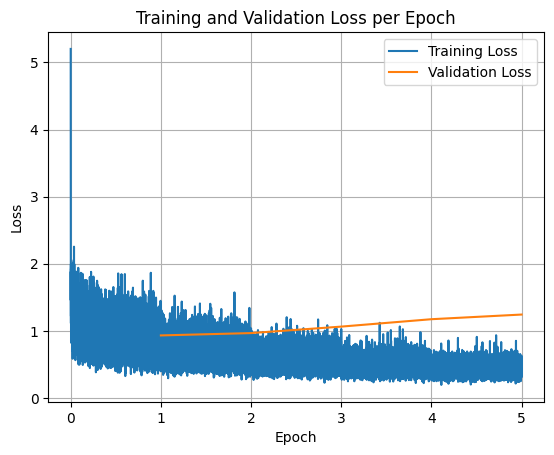

In [ ]:
%pip install matplotlib
import matplotlib.pyplot as plt

# Access the log history
log_history = trainer.state.log_history

# Extract training / validation loss
train_losses = [log["loss"] for log in log_history if "loss" in log]
epoch_train = [log["epoch"] for log in log_history if "loss" in log]
eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
epoch_eval = [log["epoch"] for log in log_history if "eval_loss" in log]

# Plot the training loss
plt.plot(epoch_train, train_losses, label="Training Loss")
plt.plot(epoch_eval, eval_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [74]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_id = "gemma-3-270m-it-ft-bash-judge"

# Load Model
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype="auto",
    device_map="auto",
    attn_implementation="eager"
)
tokenizer = AutoTokenizer.from_pretrained(model_id)

`torch_dtype` is deprecated! Use `dtype` instead!


In [75]:
from transformers import pipeline

prompt = "copy all .jpg files to /mnt/backup"
cmd = "cp *.jpg /mnt/backup/"
model_input = {
    "messages": [
          {"role": "system", "content": "You are a helpful assistant that confirms that a bash command matches a description."},
                {"role": "user", "content": "Does the following command match this description: '" + prompt + "'?" + "\n\nCommand: `" + cmd + "`"},
      ]
}

In [76]:
generator = pipeline("text-generation", model="micrictor/gemma-3-270m-it-ft-bash-judge", device="cpu")
output = generator(model_input["messages"],
    max_new_tokens=16,
    disable_compile=True,
    clean_up_tokenization_spaces=False,
    return_full_text=False,
)[0]
print(output["generated_text"])

c:\Users\micri\Documents\shellai_train\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\micri\.cache\huggingface\hub\models--micrictor--gemma-3-270m-it-ft-bash-judge. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Fal

yes


In [81]:
prompt = "make a web request to google.com"
cmd = "curl -I google http://www.facebook.com"
model_input = {
    "messages": [
            {"role": "system", "content": "You are a helpful assistant that confirms that a bash command matches a description."},
            {"role": "user", "content": "Does the following command match this description: '" + prompt + "'?" + "\n\nCommand: `" + cmd + "`"},
      ]
}
output = generator(model_input["messages"],
    max_new_tokens=16,
    disable_compile=True,
    clean_up_tokenization_spaces=False,
    return_full_text=False,
)[0]
print(output["generated_text"])

yes
